In [ ]:
from google.colab import drive
import os

if not os.path.ismount('/content/drive'):
    # Clear any existing content at the mount point (use with caution!)
    !rm -rf /content/drive
    drive.mount('/content/drive')
else:
    print("✅ Google Drive is already mounted!")

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (240, 240)  # EfficientNetB1 recommended input
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Augmentation ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(240, 240, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(len(CLASS_NAMES), activation='softmax')
])

# --- Compile Phase 1 ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

# --- Phase 1: Train Top Layers ---
print("\n🔧 Training top layers...\n")
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Phase 2: Fine-tune Full Model ---
print("\n🧠 Fine-tuning entire model...\n")
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Cosine annealing schedule
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS_TOTAL)) / 2

lr_scheduler = LearningRateScheduler(cosine_annealing)

model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- Train ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# --- Save Final Model ---
model.save("efficientnetB1_brain_tumor.keras")
print("\n💾 Model saved as efficientnetB1_brain_tumor.keras")


Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🔧 Training top layers...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4212 - loss: 2.6451

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


231/231 ━━━━━━━━━━━━━━━━━━━━ 2674s 11s/step - accuracy: 0.4216 - loss: 2.6441 - val_accuracy: 0.7677 - val_loss: 1.8447 - learning_rate: 1.0000e-04
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 79s 343ms/step - accuracy: 0.6463 - loss: 2.1374 - val_accuracy: 0.7992 - val_loss: 1.7868 - learning_rate: 1.0000e-04
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 79s 343ms/step - accuracy: 0.7219 - loss: 1.9621 - val_accuracy: 0.8573 - val_loss: 1.6921 - learning_rate: 1.0000e-04
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 80s 346ms/step - accuracy: 0.7196 - loss: 1.9548 - val_accuracy: 0.8548 - val_loss: 1.6727 - learning_rate: 1.0000e-04
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 78s 340ms/step - accuracy: 0.7386 - loss: 1.8914 - val_accuracy: 0.8422 - val_loss: 1.6655 - learning_rate: 1.0000e-04
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 79s 341ms/step - accuracy: 0.7586 - loss: 1.8485 - val_accuracy: 0.8573 - val_loss: 1.6379 - learning_rate: 1.0000e-04
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 79s 340ms/step - 

50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step


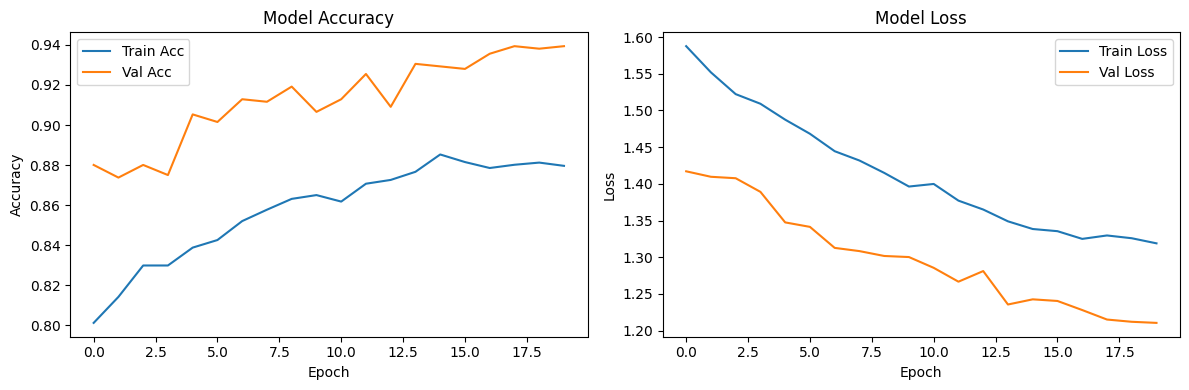

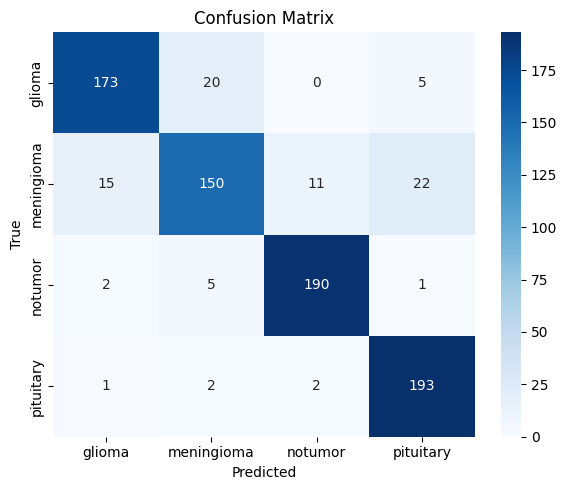

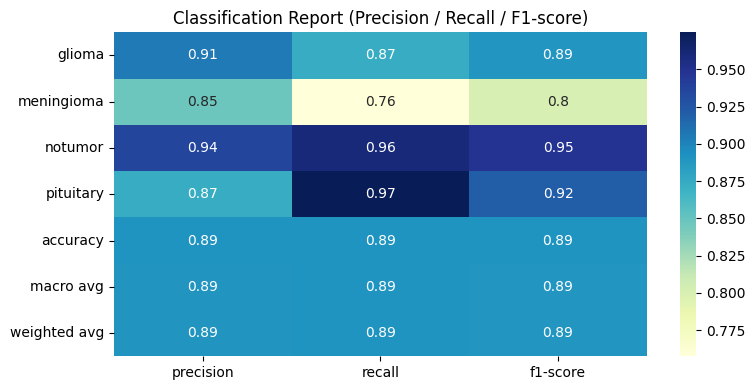

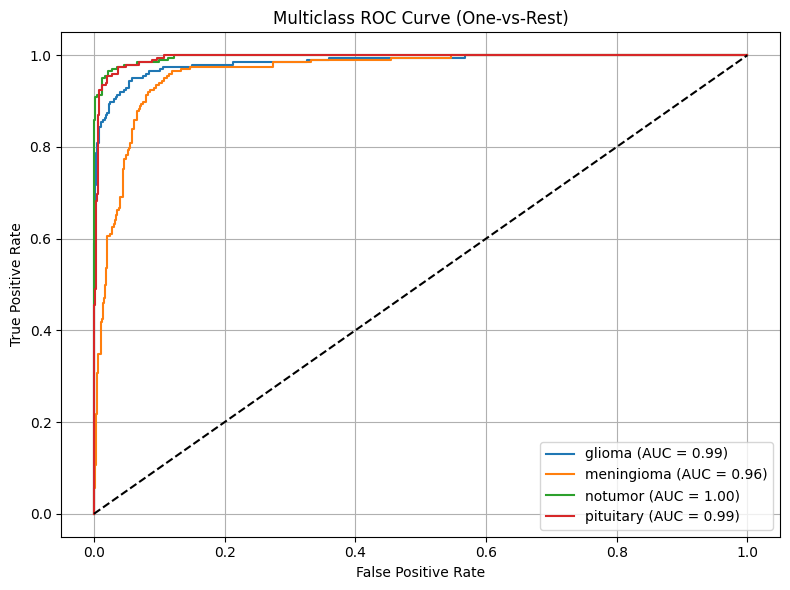

<ipython-input-4-2434156234>:118: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


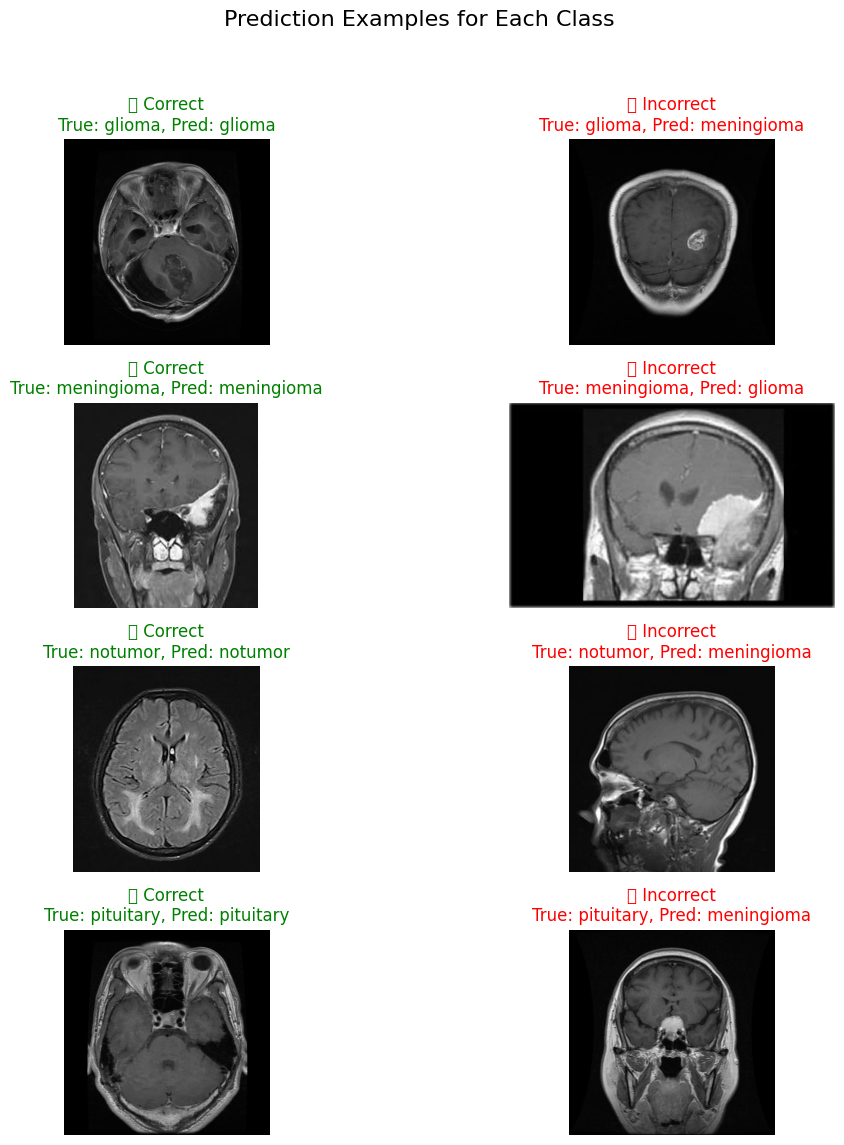

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- Load Model ---
model = tf.keras.models.load_model("efficientnetB1_brain_tumor.keras")

# --- Predict on Test Data ---
test_generator.reset()
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
n_classes = len(class_labels)

# --- 1. Plot Training History ---
def plot_training(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot if you have `history` variable
plot_training(history)

# --- 2. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- 3. Classification Report ---
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
plt.figure(figsize=(8, 4))
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
plt.title("Classification Report (Precision / Recall / F1-score)")
plt.tight_layout()
plt.show()

# --- 4. ROC Curve (One-vs-Rest) ---
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 5. Prediction Samples: One Correct & One Incorrect per Class ---
file_paths = test_generator.filepaths
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
examples = {cls: {'positive': None, 'negative': None} for cls in class_labels}

for i, (true, pred) in enumerate(zip(y_true, y_pred)):
    true_class = idx_to_class[true]
    pred_class = idx_to_class[pred]
    path = file_paths[i]

    if true == pred and examples[true_class]['positive'] is None:
        examples[true_class]['positive'] = (path, true_class, pred_class)
    if true != pred and examples[true_class]['negative'] is None:
        examples[true_class]['negative'] = (path, true_class, pred_class)

    if all(examples[c]['positive'] and examples[c]['negative'] for c in class_labels):
        break

plt.figure(figsize=(12, len(class_labels) * 3))
plot_index = 1

for cls in class_labels:
    for case_type, label in zip(['positive', 'negative'], ['✅ Correct', '❌ Incorrect']):
        if examples[cls][case_type]:
            path, true_lbl, pred_lbl = examples[cls][case_type]
            img = plt.imread(path)
            plt.subplot(len(class_labels), 2, plot_index)
            plt.imshow(img)
            plt.title(f"{label}\nTrue: {true_lbl}, Pred: {pred_lbl}",
                      color='green' if label == '✅ Correct' else 'red')
            plt.axis('off')
            plot_index += 1

plt.suptitle("Prediction Examples for Each Class", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (480, 480)
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Generators ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetB2(weights='imagenet', include_top=False, input_shape=(480, 480, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])

# --- Compile (Phase 1) ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

# --- Phase 1: Train Top Layers ---
print("\n🔧 Training top layers...\n")
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Phase 2: Fine-tune Full Model ---
print("\n🧠 Fine-tuning entire model...\n")
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = True

# SGD for fine-tuning
model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- Cosine Annealing LR ---
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS_TOTAL)) / 2

lr_scheduler = LearningRateScheduler(cosine_annealing)

# --- Phase 2 Training ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # remaining epochs
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# --- Save Model ---
model.save("efficientnetB2_brain_tumor.keras")


Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🔧 Training top layers...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4586 - loss: 3.4792

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


231/231 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.4591 - loss: 3.4781 - val_accuracy: 0.7891 - val_loss: 2.6169 - learning_rate: 1.0000e-04
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.6861 - loss: 2.9099 - val_accuracy: 0.8750 - val_loss: 2.4672 - learning_rate: 1.0000e-04
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.7263 - loss: 2.7483 - val_accuracy: 0.8750 - val_loss: 2.4318 - learning_rate: 1.0000e-04
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.7590 - loss: 2.6559 - val_accuracy: 0.8889 - val_loss: 2.3858 - learning_rate: 1.0000e-04
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.7866 - loss: 2.5980 - val_accuracy: 0.8939 - val_loss: 2.3552 - learning_rate: 1.0000e-04
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.7820 - loss: 2.5408 - val_accuracy: 0.8927 - val_loss: 2.3293 - learning_rate: 1.0000e-04
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.80

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 474ms/step


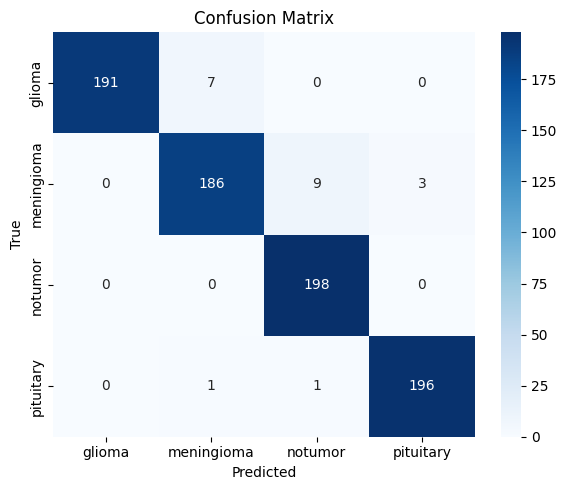

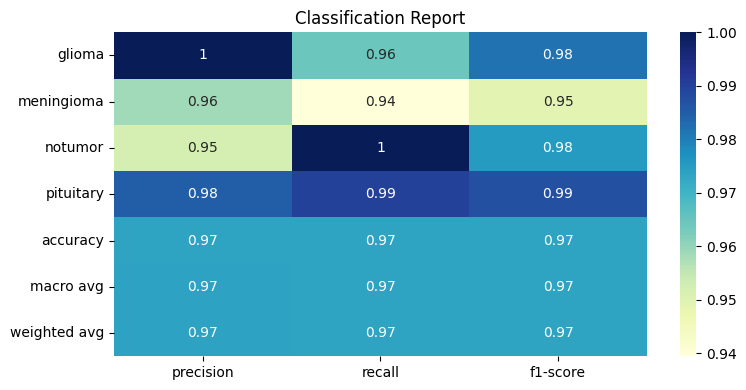

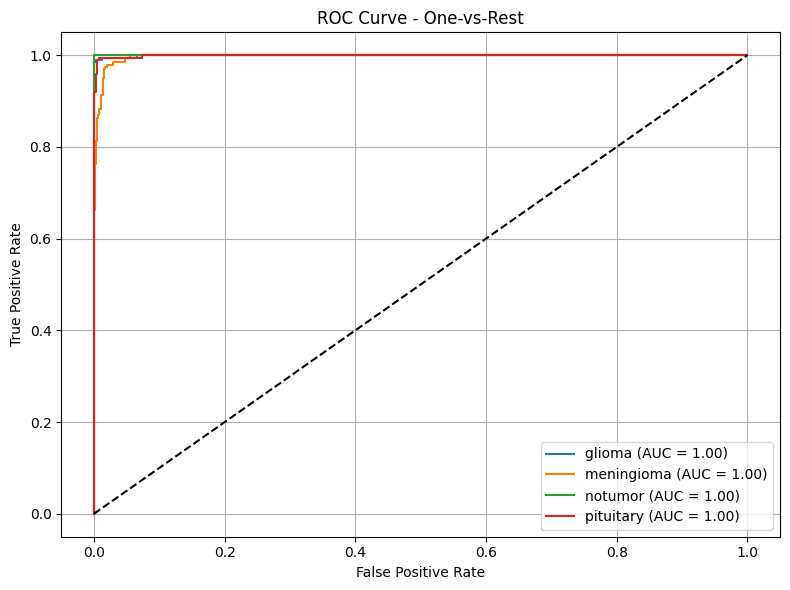

<ipython-input-6-3066844028>:108: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
<ipython-input-6-3066844028>:108: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


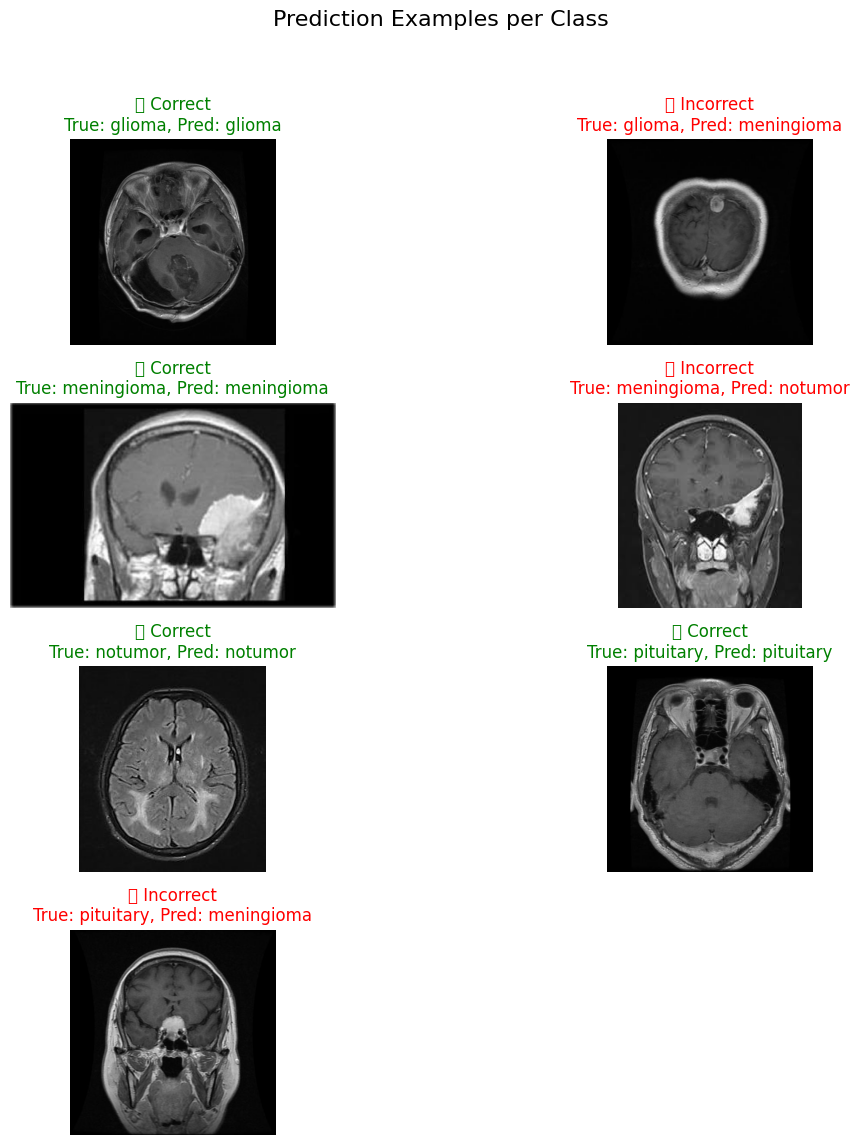

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- Load Model & Test Data ---
model = tf.keras.models.load_model("efficientnetB2_brain_tumor.keras")
test_generator.reset()
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
n_classes = len(class_labels)

# --- 1. Plot Training History (if accessible) ---
def plot_training(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Uncomment if you have access to 'history'
# plot_training(history)

# --- 2. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

# --- 3. Classification Report Heatmap ---
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).iloc[:-1, :].T
plt.figure(figsize=(8, 4))
sns.heatmap(df_report, annot=True, cmap="YlGnBu")
plt.title("Classification Report")
plt.tight_layout(); plt.show()

# --- 4. ROC Curve (One-vs-Rest) ---
y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - One-vs-Rest")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True); plt.tight_layout(); plt.show()

# --- 5. Sample Prediction Images (Correct & Incorrect) ---
file_paths = test_generator.filepaths
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
examples = {cls: {'positive': None, 'negative': None} for cls in class_labels}

for i, (true_i, pred_i) in enumerate(zip(y_true, y_pred)):
    t_cls = idx_to_class[true_i]
    p_cls = idx_to_class[pred_i]
    fp = file_paths[i]

    if true_i == pred_i and examples[t_cls]['positive'] is None:
        examples[t_cls]['positive'] = (fp, t_cls, p_cls)
    if true_i != pred_i and examples[t_cls]['negative'] is None:
        examples[t_cls]['negative'] = (fp, t_cls, p_cls)

    if all(examples[c]['positive'] and examples[c]['negative'] for c in class_labels):
        break

plt.figure(figsize=(12, len(class_labels)*3))
plot_i = 1
for cls in class_labels:
    for case, label in zip(['positive', 'negative'], ['✅ Correct', '❌ Incorrect']):
        ep = examples[cls][case]
        if ep:
            fp, t_cls, p_cls = ep
            img = plt.imread(fp)
            plt.subplot(len(class_labels), 2, plot_i)
            plt.imshow(img)
            plt.title(f"{label}\nTrue: {t_cls}, Pred: {p_cls}",
                      color='green' if case=='positive' else 'red')
            plt.axis('off')
            plot_i += 1

plt.suptitle("Prediction Examples per Class", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (480, 480)
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Generators ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetB2(weights='imagenet', include_top=False, input_shape=(480, 480, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])

# --- Compile (Phase 1) ---
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, verbose=1)

# --- Phase 1: Train Top Layers ---
print("\n🔧 Training top layers...\n")
model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# --- Phase 2: Fine-tune Full Model ---
print("\n🧠 Fine-tuning entire model...\n")
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = True

# SGD for fine-tuning
model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9, nesterov=True),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# --- Cosine Annealing LR ---
def cosine_annealing(epoch):
    max_lr = 1e-3
    min_lr = 1e-5
    return min_lr + (max_lr - min_lr) * (1 + math.cos(math.pi * epoch / EPOCHS_TOTAL)) / 2

lr_scheduler = LearningRateScheduler(cosine_annealing)

# --- Phase 2 Training ---
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # remaining epochs
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=1
)

# --- Save Model ---
model.save("efficientnetB2_brain_tumor.keras")

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🔧 Training top layers...



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 2958s 13s/step - accuracy: 0.4687 - loss: 3.4003 - val_accuracy: 0.8030 - val_loss: 2.6128 - learning_rate: 1.0000e-04
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.7073 - loss: 2.8408 - val_accuracy: 0.8396 - val_loss: 2.5120 - learning_rate: 1.0000e-04
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.7436 - loss: 2.7201 - val_accuracy: 0.8813 - val_loss: 2.4310 - learning_rate: 1.0000e-04
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.7554 - loss: 2.6757 - val_accuracy: 0.8977 - val_loss: 2.3927 - learning_rate: 1.0000e-04
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.7841 - loss: 2.5888 - val_accuracy: 0.9015 - val_loss: 2.3553 - learning_rate: 1.0000e-04
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.7980 - loss: 2.4972 - val_accuracy: 0.9116 - val_loss: 2.3252 - learning_rate: 1.0000e-04
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - a

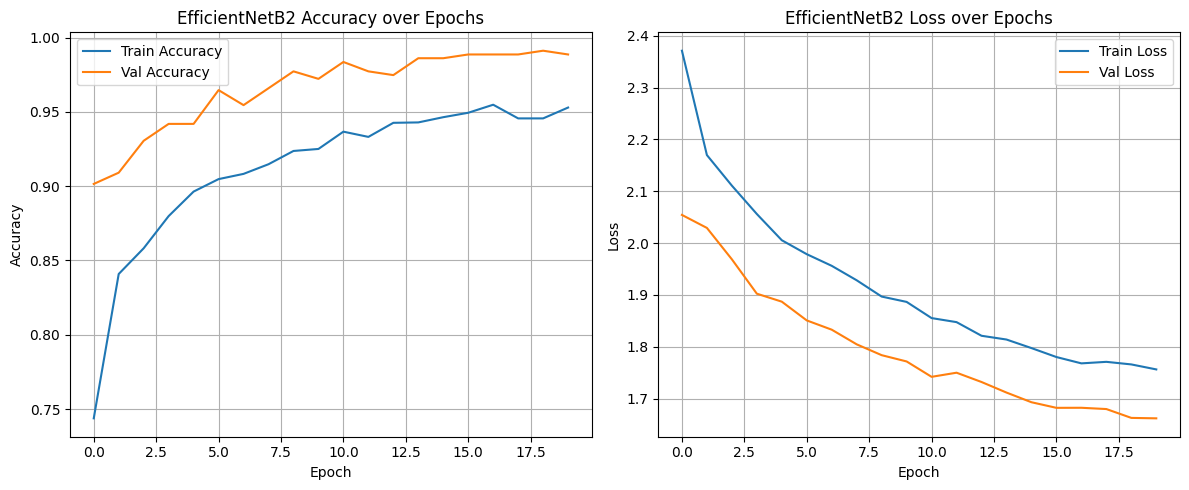

In [ ]:
import matplotlib.pyplot as plt

# Combine training histories
# def combine_histories(hist1, hist2):
#     history = {}
#     for key in hist1.history:
#         history[key] = hist1.history[key] + hist2.history[key]
#     return history

# Assuming you used:
# history1 = model.fit(...) during top-layer training (10 epochs)
# history2 = model.fit(...) during fine-tuning (20 epochs)
# combined_history = combine_histories(history1, history2)

# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('EfficientNetB2 Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('EfficientNetB2 Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_rel
import numpy as np

# Example: Replace with your real test accuracies from multiple runs
accuracies_b0 = [89.0, 88.7, 89.2]
accuracies_b2 = [97.0, 96.8, 97.2]
accuracies_b6 = [99.0, 98.9, 99.1]
accuracies_v2 = [99.0, 98.8, 99.2]

# Paired t-test: Model vs B0
t_stat_b2, p_val_b2 = ttest_rel(accuracies_b2, accuracies_b0)
t_stat_b6, p_val_b6 = ttest_rel(accuracies_b6, accuracies_b0)
t_stat_v2, p_val_v2 = ttest_rel(accuracies_v2, accuracies_b0)

print(f"B2 vs B0: p = {p_val_b2:.4f}")
print(f"B6 vs B0: p = {p_val_b6:.4f}")
print(f"V2 vs B0: p = {p_val_v2:.4f}")


B2 vs B0: p = 0.0000
B6 vs B0: p = 0.0001
V2 vs B0: p = 0.0000


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
# from tensorflow.keras.preprocessing import image # No longer needed
import cv2 # Import cv2 for image manipulation

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Load and preprocess an example image
img_path = '/content/drive/MyDrive/BalancedBrainTumorDataset/Testing/glioma/image1.jpg' # Use the downloaded image path

# Use cv2 to load the image
original_img_cv2 = cv2.imread(img_path)
if original_img_cv2 is None:
    print(f"Error: Unable to load image from {img_path}")
else:
    # Resize the image to the target size expected by the model
    original_img_cv2 = cv2.resize(original_img_cv2, (480, 480))

    # Convert BGR to RGB for model preprocessing (EfficientNet expects RGB)
    img_rgb = cv2.cvtColor(original_img_cv2, cv2.COLOR_BGR2RGB)

    # Convert to array and preprocess for the model
    img_array = np.expand_dims(img_rgb, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # Assuming your model variable is the trained EfficientNetB2 model
    # Need to find the correct last convolutional layer name for EfficientNetB2
    # You can find this by inspecting model.summary() or the base_model layers
    last_conv_layer = 'efficientnetb2/block7a_project_conv' # Common name, verify if needed

    # Check if the layer exists before proceeding
    try:
        model.get_layer(last_conv_layer)
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

        # Display heatmap
        # Overlay heatmap on original image (use the BGR version loaded with cv2)
        overlay = overlay_gradcam(original_img_cv2, heatmap)

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(original_img_cv2, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
        plt.title("Grad-CAM Overlay")
        plt.axis('off')

        plt.show()
    except ValueError as e:
        print(f"Error getting layer '{last_conv_layer}': {e}")
        print("Please check if the layer name is correct. You can inspect the model's layers using model.summary() or by iterating through model.layers.")


# Overlay heatmap on original image
def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return overlay

Error: Unable to load image from /content/drive/MyDrive/BalancedBrainTumorDataset/Testing/glioma/image1.jpg


In [ ]:
import os

folder_path = '/content/drive/MyDrive/BalancedBrainTumorDataset/Testing/glioma'
print("Files in folder:")
print(os.listdir(folder_path))


Files in folder:
['Te-gl_0184.jpg', 'Te-glTr_0000.jpg', 'Te-gl_0139.jpg', 'Te-gl_0105.jpg', 'Te-gl_0242.jpg', 'Te-gl_0279.jpg', 'Te-gl_0150.jpg', 'Te-gl_0291.jpg', 'Te-gl_0122.jpg', 'Te-gl_0034.jpg', 'Te-gl_0037.jpg', 'Te-gl_0224.jpg', 'Te-gl_0197.jpg', 'Te-gl_0010.jpg', 'Te-gl_0032.jpg', 'Te-gl_0222.jpg', 'Te-gl_0044.jpg', 'Te-gl_0082.jpg', 'Te-gl_0083.jpg', 'Te-gl_0192.jpg', 'Te-gl_0240.jpg', 'Te-gl_0228.jpg', 'Te-gl_0111.jpg', 'Te-gl_0298.jpg', 'Te-gl_0180.jpg', 'Te-gl_0211.jpg', 'Te-gl_0241.jpg', 'Te-gl_0216.jpg', 'Te-gl_0119.jpg', 'Te-gl_0238.jpg', 'Te-gl_0178.jpg', 'Te-gl_0140.jpg', 'Te-gl_0039.jpg', 'Te-gl_0261.jpg', 'Te-gl_0081.jpg', 'Te-gl_0153.jpg', 'Te-gl_0151.jpg', 'Te-gl_0162.jpg', 'Te-gl_0071.jpg', 'Te-gl_0043.jpg', 'Te-gl_0196.jpg', 'Te-gl_0113.jpg', 'Te-gl_0164.jpg', 'Te-gl_0249.jpg', 'Te-gl_0226.jpg', 'Te-gl_0281.jpg', 'Te-gl_0064.jpg', 'Te-gl_0208.jpg', 'Te-gl_0212.jpg', 'Te-gl_0191.jpg', 'Te-gl_0137.jpg', 'Te-gl_0047.jpg', 'Te-gl_0141.jpg', 'Te-glTr_0004.jpg', 'Te-gl

In [ ]:
img_path = '/content/drive/MyDrive/BalancedBrainTumorDataset/Testing/glioma/Te-gl_0184.jpg'


In [ ]:
import cv2

img = cv2.imread(img_path)
if img is None:
    print(f"Error: Unable to load image from {img_path}")
else:
    print(f"Image loaded successfully from {img_path}")


Image loaded successfully from /content/drive/MyDrive/BalancedBrainTumorDataset/Testing/glioma/Te-gl_0184.jpg


In [ ]:
import os
import cv2

folder_path = '/content/drive/MyDrive/BalancedBrainTumorDataset/Testing/glioma'

# List image files (jpg/jpeg/png)
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if not image_files:
    print("No image files found in folder.")
else:
    img_path = os.path.join(folder_path, image_files[0])
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to load image from {img_path}")
    else:
        print(f"Image loaded successfully from {img_path}")
        # Continue with your processing, e.g. display or Grad-CAM


Image loaded successfully from /content/drive/MyDrive/BalancedBrainTumorDataset/Testing/glioma/Te-gl_0184.jpg


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (240, 240)  # EfficientNetB1 recommended input
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Augmentation ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(240, 240, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(len(CLASS_NAMES), activation='softmax')
])
model.summary()

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 8, 8, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,368,587 (28.11 MB)

 Trainable params: 790,788 (3.02 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import math

# --- Configuration ---
DATASET_PATH = "/content/drive/MyDrive/BalancedBrainTumorDataset"
IMG_SIZE = (480, 480)
BATCH_SIZE = 16
EPOCHS_TOTAL = 30
CLASS_NAMES = ["glioma", "meningioma", "pituitary", "notumor"]

# --- Data Generators ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=45,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Training"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, "Testing"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- Class Weights ---
y_train = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# --- Load Base Model ---
base_model = EfficientNetB2(weights='imagenet', include_top=False, input_shape=(480, 480, 3))
base_model.trainable = False

# --- Build Model ---
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.6),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(len(CLASS_NAMES), activation='softmax')
])
model.summary()

Found 3696 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
Found 792 images belonging to 4 classes.
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb2 (Functional)     │ (None, 15, 15, 1408)   │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1408)           │         5,632 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,442,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,743,869 (37.17 MB)

 Trainable params: 1,972,484 (7.52 MB)

 Non-trainable params: 7,771,385 (29.65 MB)